In [1]:
#Instalar librerias
!pip install catboost
!pip install shap
!pip install xgboost
!pip install optbinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 18.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.


In [2]:
#Importo librerias necesarias para el proceso de EDA (Esploratory Data Analysis)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
import numpy as np
from datetime import datetime

#Importo librerias necesarias para el proceso de Feature engineering y evaluación de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay

#Importo librerias necesarias para ML
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
import shap

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# URL de GitHub
flu = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/training_set_features.csv"
flu_labels = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/training_set_labels.csv"
flu_test = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/test_set_features.csv"

# Carga los datos
flu_df = pd.read_csv(flu)
print(flu_df.head())

flu_labels_df = pd.read_csv(flu_labels)
print(flu_labels_df.head())

flu_test_df = pd.read_csv(flu_test)
print(flu_test_df.head())

   respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
0              0           1.0             0.0                        0.0   
1              1           3.0             2.0                        0.0   
2              2           1.0             1.0                        0.0   
3              3           1.0             1.0                        0.0   
4              4           2.0             1.0                        0.0   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0                   0.0                   0.0                    0.0   
1                   1.0                   0.0                    1.0   
2                   1.0                   0.0                    0.0   
3                   1.0                   0.0                    1.0   
4                   1.0                   0.0                    1.0   

   behavioral_large_gatherings  behavioral_outside_home  \
0                          0.0               

Primer paso, unir ambos datasets

In [4]:
flu_combinado = pd.merge(flu_df, flu_labels_df, on="respondent_id", how="inner")
flu_combinado.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [5]:
#EDA Básico

flu_combinado.info()
flu_combinado.describe()
flu_combinado.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

,0
respondent_id,0
h1n1_concern,92
h1n1_knowledge,116
behavioral_antiviral_meds,71
behavioral_avoidance,208
behavioral_face_mask,19
behavioral_wash_hands,42
behavioral_large_gatherings,87
behavioral_outside_home,82
behavioral_touch_face,128


In [6]:
#Voy a visualizar la cantidad de nulos por variables como primer fase de mi análisis
# Obtengo el número total de registros
total_records = len(flu_combinado)

# Calculo la proporción de valores nulos por cada variable
null_proportion = flu_combinado.isnull().sum() / total_records

#Lo convierto a porcentaje
null_proportion_percentage = null_proportion * 100

#Muestro en pantalla
print(null_proportion_percentage)

respondent_id                   0.000000
h1n1_concern                    0.344479
h1n1_knowledge                  0.434343
behavioral_antiviral_meds       0.265848
behavioral_avoidance            0.778822
behavioral_face_mask            0.071142
behavioral_wash_hands           0.157262
behavioral_large_gatherings     0.325757
behavioral_outside_home         0.307036
behavioral_touch_face           0.479275
doctor_recc_h1n1                8.087767
doctor_recc_seasonal            8.087767
chronic_med_condition           3.635751
child_under_6_months            3.070356
health_worker                   3.010447
health_insurance               45.957989
opinion_h1n1_vacc_effective     1.464036
opinion_h1n1_risk               1.452803
opinion_h1n1_sick_from_vacc     1.479013
opinion_seas_vacc_effective     1.729884
opinion_seas_risk               1.924589
opinion_seas_sick_from_vacc     2.010709
age_group                       0.000000
education                       5.268282
race            

In [ ]:
#Análisis estadistico de variables númericas

In [19]:
flu_combinado.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


In [7]:

#Creo función para graficar la distribución de las variables
def graficar_variables(df, bins=30, max_unique=10, figsize=(6, 4)):
    """
    Grafica histogramas para variables numéricas continuas y
    gráficos de barras para variables categóricas o discretas.
    Los valores nulos se muestran como 'NA' en los gráficos de barras.

    Parámetros:
    - df: DataFrame de entrada
    - bins: número de bins para histogramas
    - max_unique: umbral de valores únicos para considerar una variable como discreta
    - figsize: tamaño de cada gráfico
    """
    for col in df.columns:
        col_data = df[col].copy()

        # Reemplazar nulos por 'NA' si no es continua
        if not (pd.api.types.is_numeric_dtype(col_data) and col_data.nunique() > max_unique):
            col_data = col_data.fillna('NA')

        if pd.api.types.is_numeric_dtype(col_data):
            unique_vals = col_data.nunique()
            if unique_vals <= max_unique:
                tipo = 'discreta'
                plt.figure(figsize=figsize)
                sns.countplot(x=col_data, palette='viridis')
                plt.title(f'Gráfico de barras: {col} ({tipo})')
                plt.xlabel(col)
                plt.ylabel('Frecuencia')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
            else:
                tipo = 'continua'
                plt.figure(figsize=figsize)
                sns.histplot(col_data.dropna(), bins=bins, kde=True, color='steelblue')
                plt.title(f'Histograma: {col} ({tipo})')
                plt.xlabel(col)
                plt.ylabel('Frecuencia')
                plt.tight_layout()
                plt.show()
        elif pd.api.types.is_categorical_dtype(col_data) or col_data.dtype == 'object':
            tipo = 'categórica'
            plt.figure(figsize=figsize)
            sns.countplot(x=col_data, palette='magma', order=pd.Series(col_data).value_counts().index)
            plt.title(f'Gráfico de barras: {col} ({tipo})')
            plt.xlabel(col)
            plt.ylabel('Frecuencia')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()



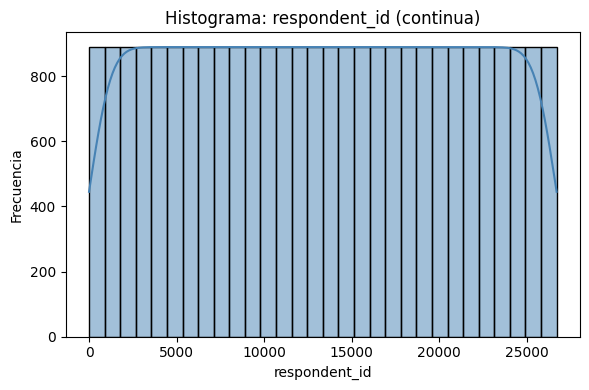

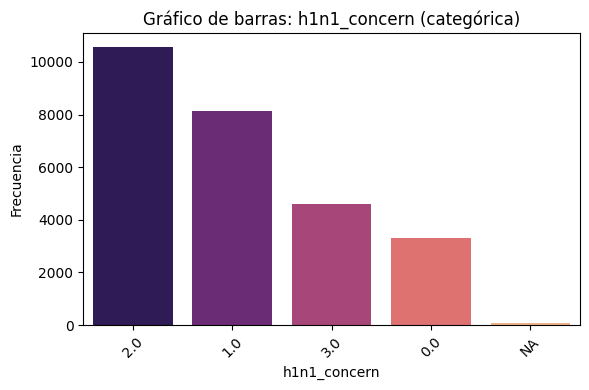

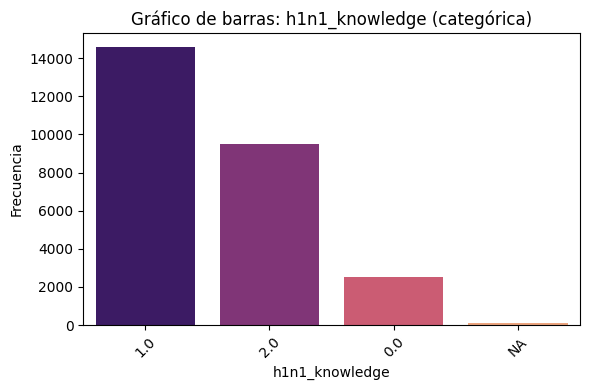

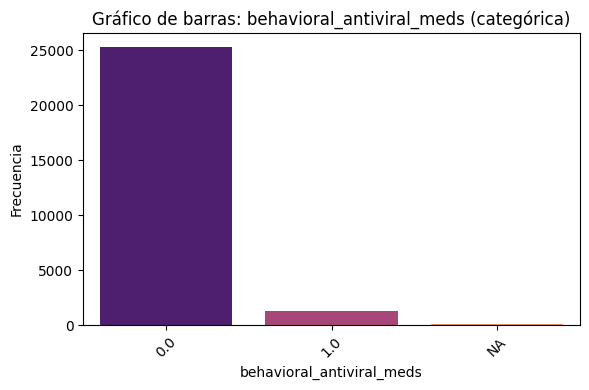

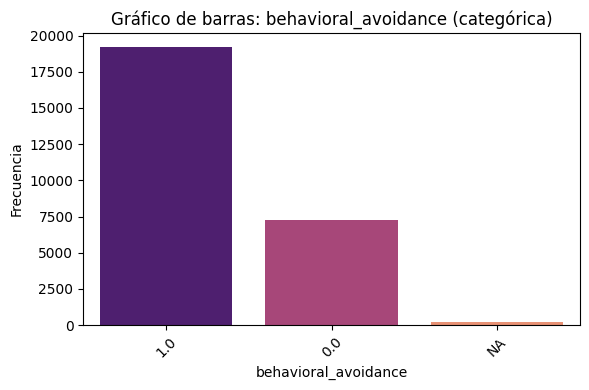

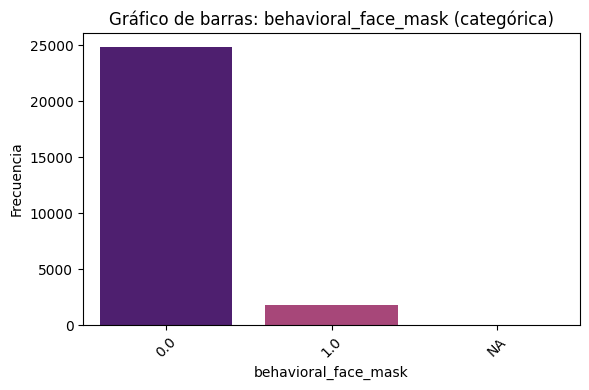

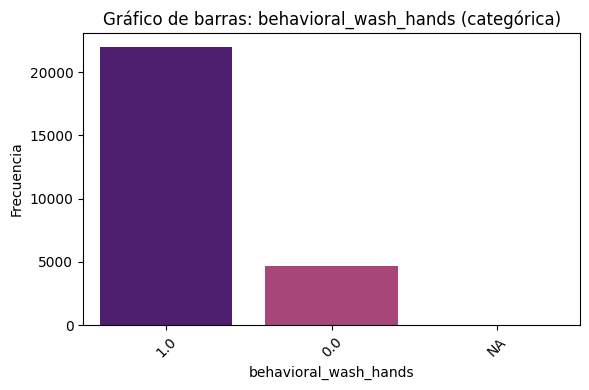

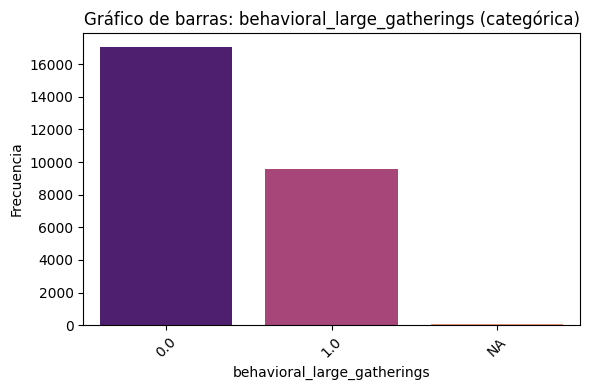

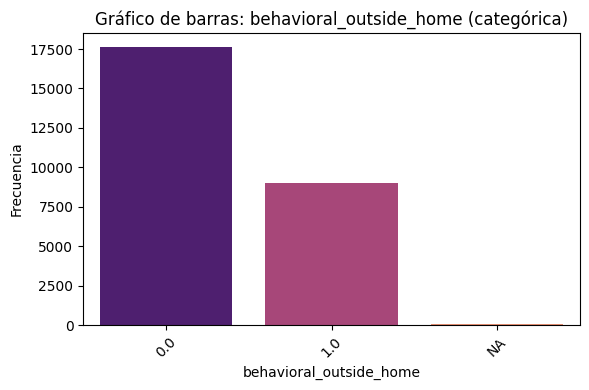

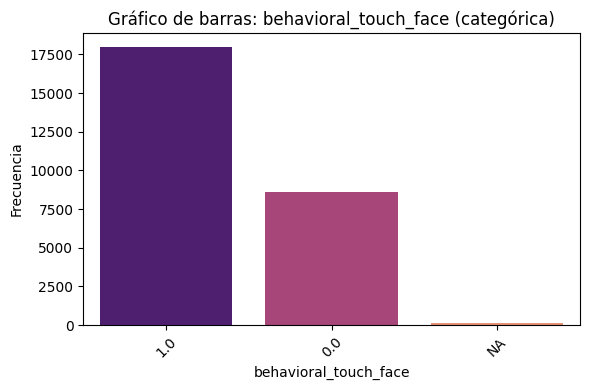

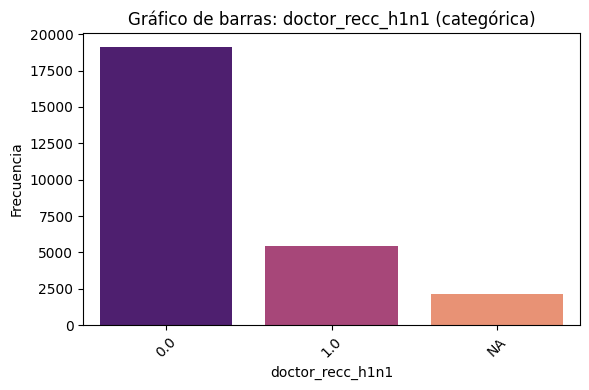

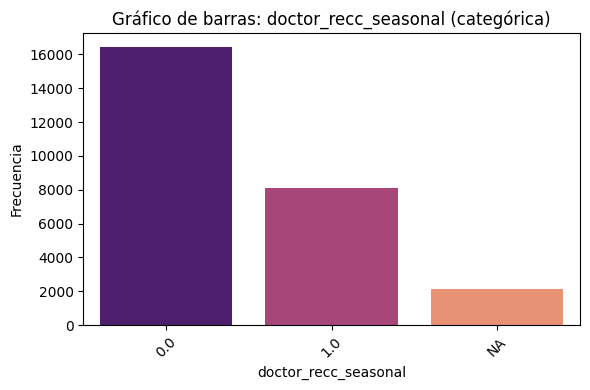

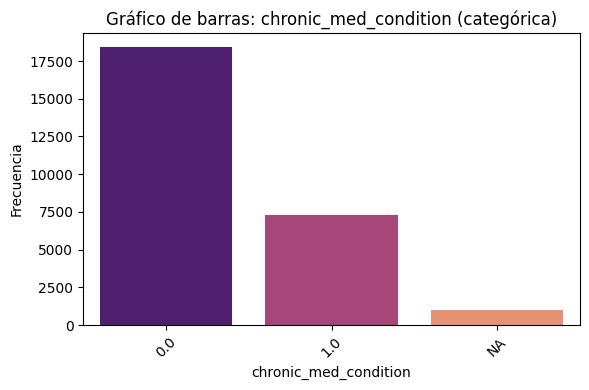

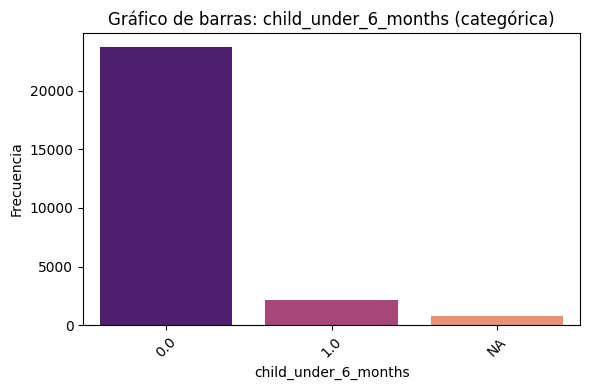

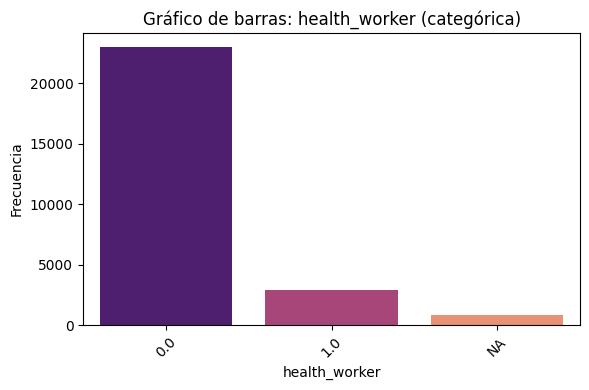

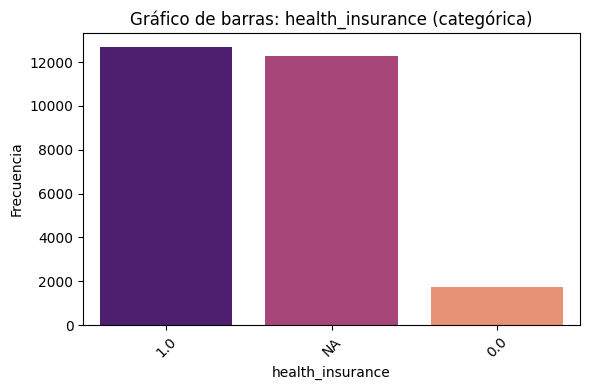

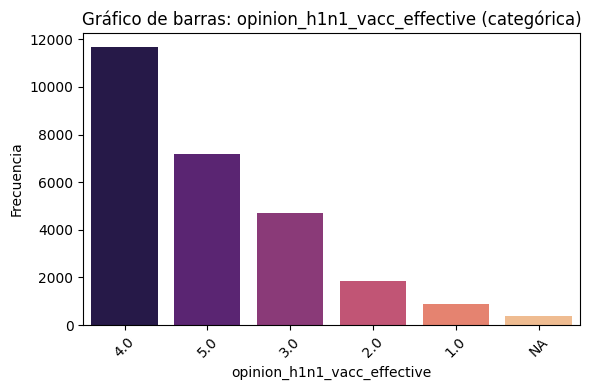

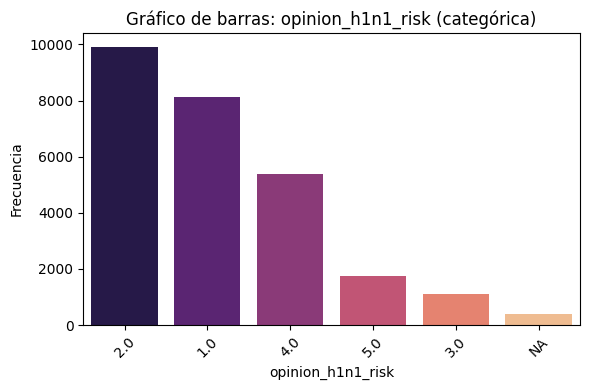

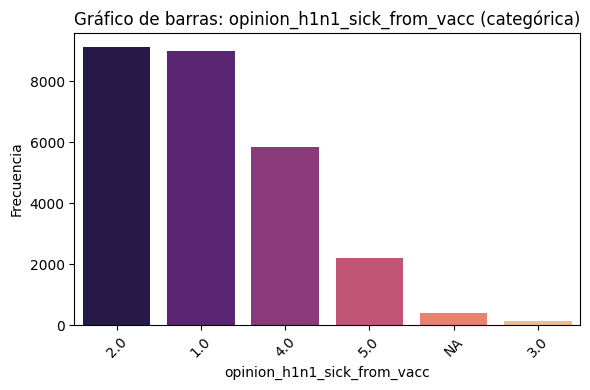

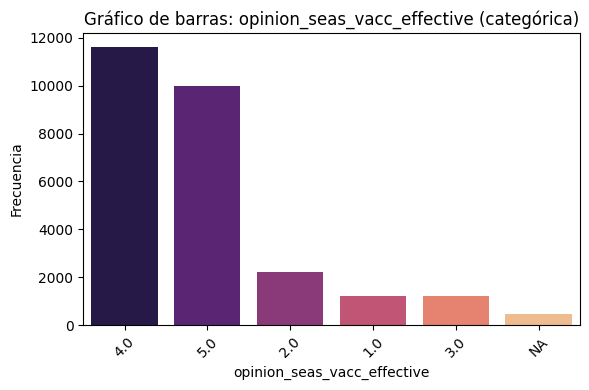

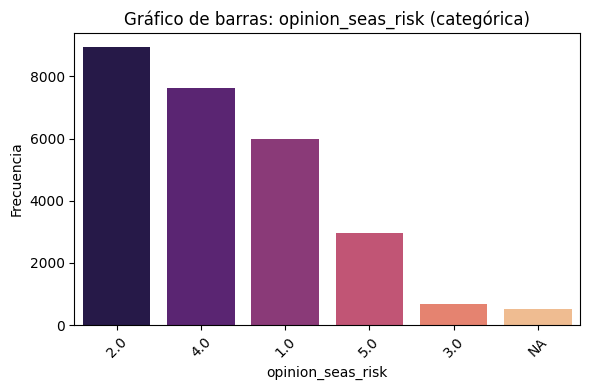

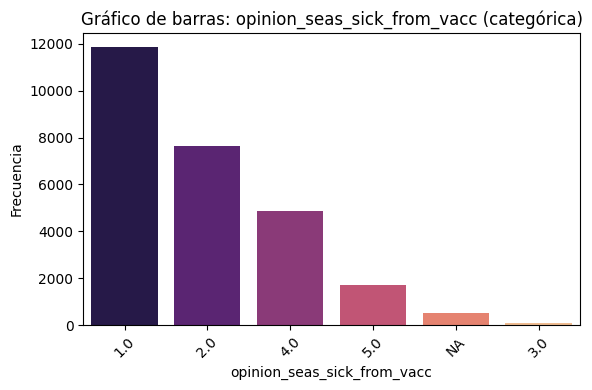

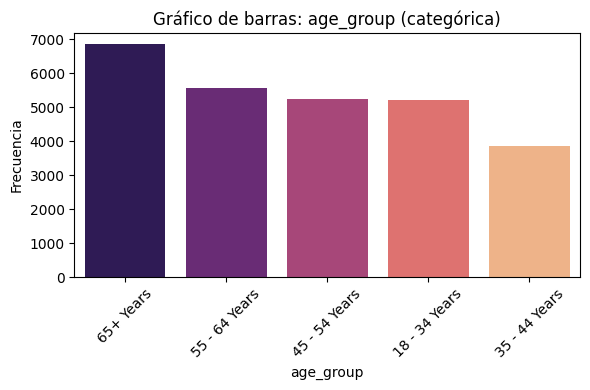

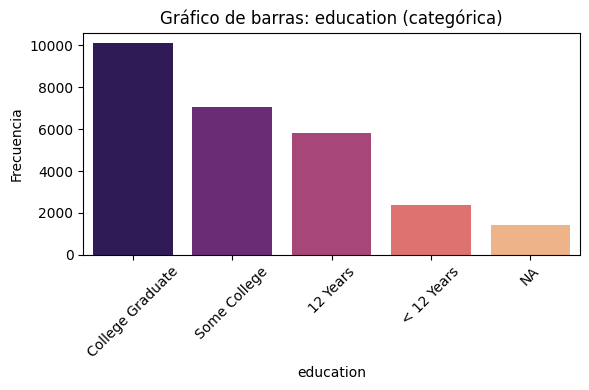

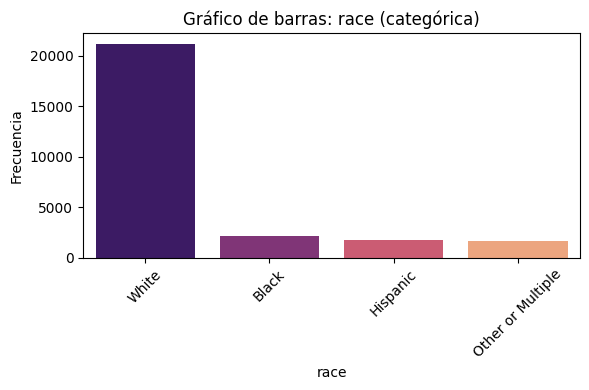

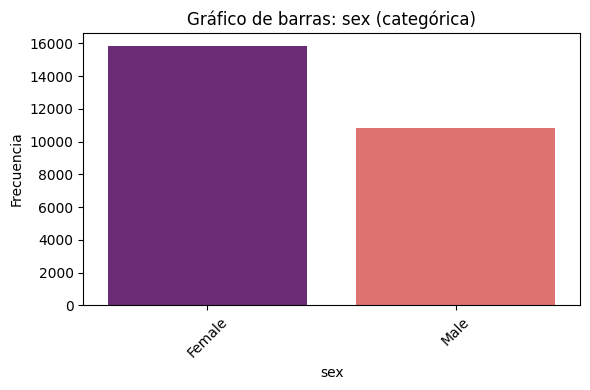

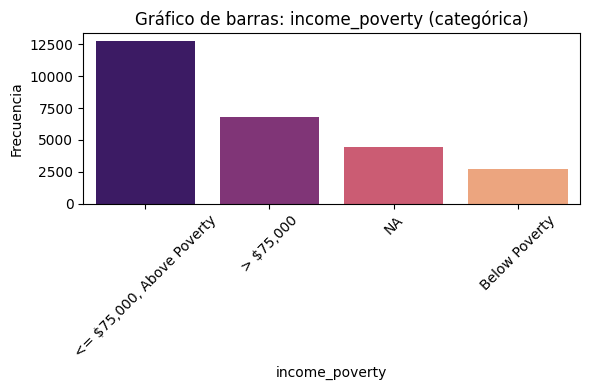

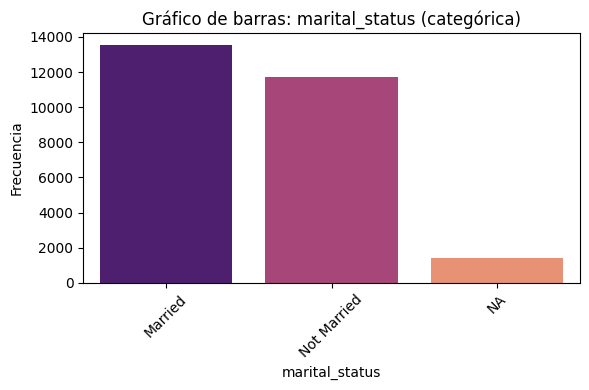

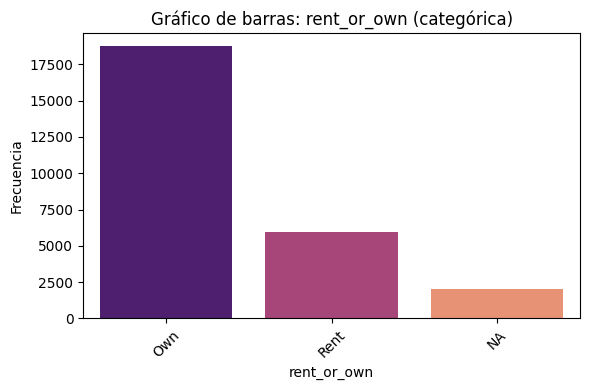

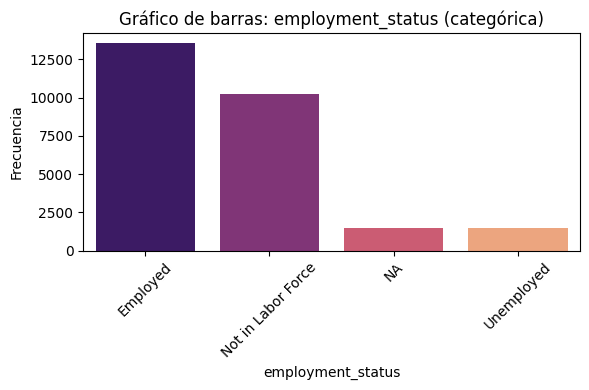

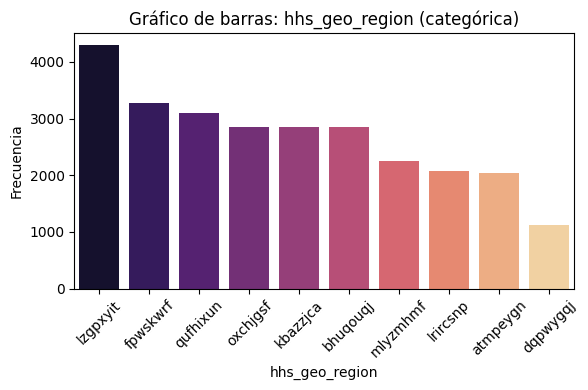

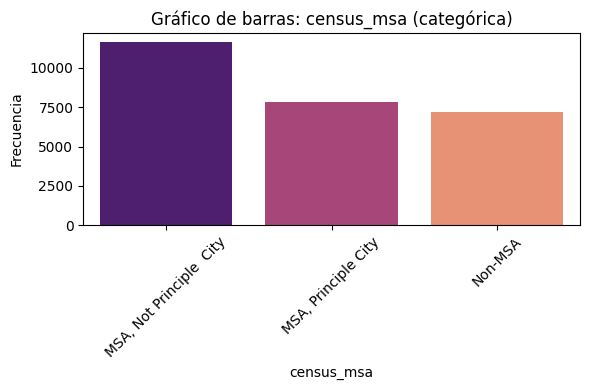

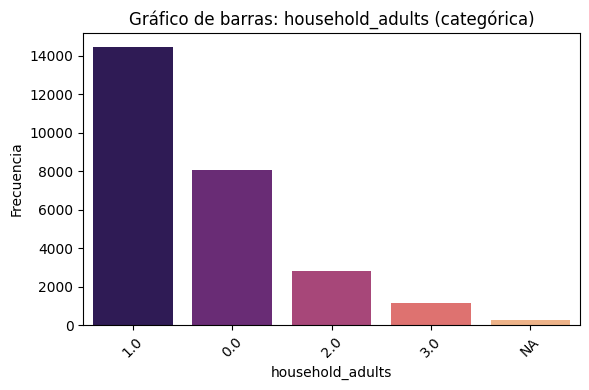

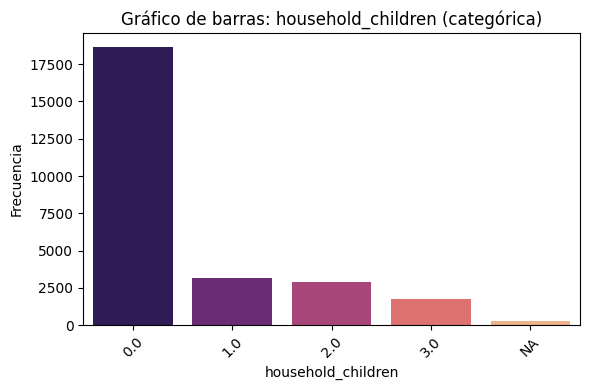

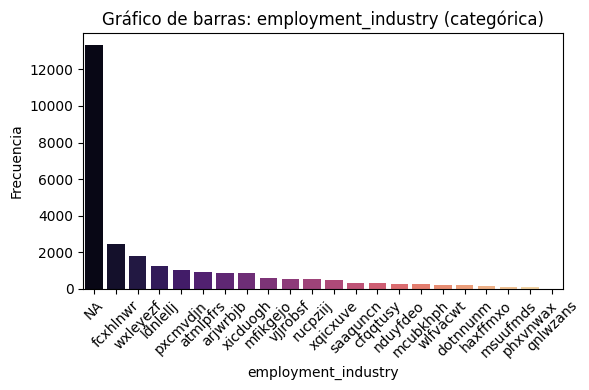

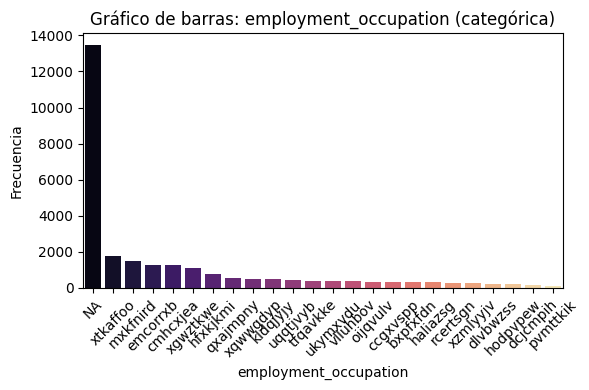

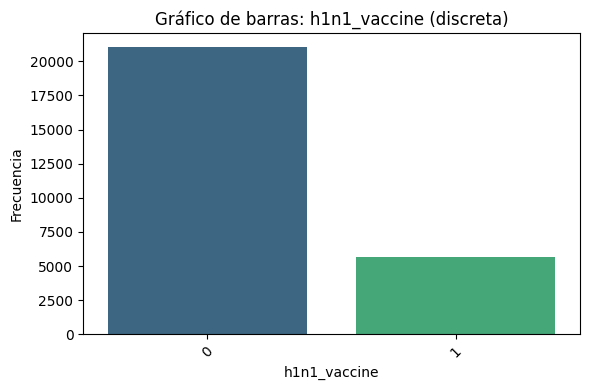

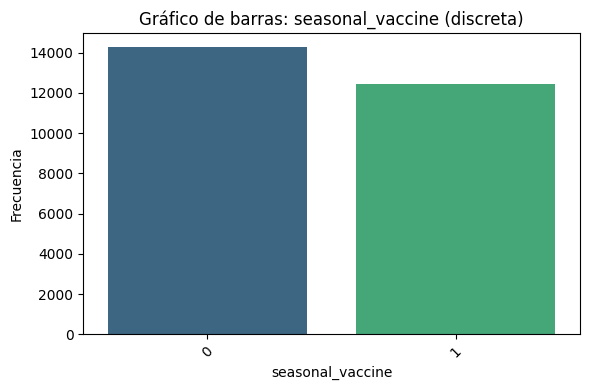

In [8]:
graficar_variables(flu_combinado)


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def comparar_distribuciones(df, var1, var2, normalize=False, cmap='Blues', annot=True, figsize=(6, 4)):
    """
    Crea una tabla de contingencia entre dos variables y la visualiza como heatmap.

    Parámetros:
    - df: DataFrame de entrada
    - var1, var2: nombres de las columnas a comparar
    - normalize: si True, normaliza por filas
    - cmap: paleta de colores del heatmap
    - annot: si True, muestra los valores en cada celda
    - figsize: tamaño del gráfico
    """
    tabla = pd.crosstab(df[var1], df[var2], normalize='index' if normalize else False)

    plt.figure(figsize=figsize)
    sns.heatmap(tabla, annot=annot, cmap=cmap, fmt='.2f' if normalize else 'd')
    plt.title(f'Distribución conjunta: {var1} vs {var2}')
    plt.xlabel(var2)
    plt.ylabel(var1)
    plt.tight_layout()
    plt.show()


Comparare las distriubuciones de las variables con altos NA relacionadas a empleo, es muy probable que los NA sean que no tienen empleo

In [20]:
tabla1 = pd.crosstab( flu_combinado['employment_industry'].fillna('NA'),flu_combinado['employment_status'].fillna('NA'))
tabla1


employment_status,Employed,NA,Not in Labor Force,Unemployed
employment_industry,,,,
NA,183,1463,10231,1453
arjwrbjb,871,0,0,0
atmlpfrs,926,0,0,0
cfqqtusy,325,0,0,0
dotnnunm,201,0,0,0
fcxhlnwr,2468,0,0,0
haxffmxo,148,0,0,0
ldnlellj,1231,0,0,0
mcubkhph,275,0,0,0


In [21]:
tabla2 = pd.crosstab( flu_combinado['employment_occupation'].fillna('NA'),flu_combinado['employment_status'].fillna('NA'))
tabla2

employment_status,Employed,NA,Not in Labor Force,Unemployed
employment_occupation,,,,
NA,323,1463,10231,1453
bxpfxfdn,331,0,0,0
ccgxvspp,341,0,0,0
cmhcxjea,1247,0,0,0
dcjcmpih,148,0,0,0
dlvbwzss,227,0,0,0
emcorrxb,1270,0,0,0
haliazsg,296,0,0,0
hfxkjkmi,766,0,0,0


In [22]:
tabla3 = pd.crosstab( flu_combinado['health_insurance'].fillna('NA'),flu_combinado['employment_status'].fillna('NA'))
tabla3

employment_status,Employed,NA,Not in Labor Force,Unemployed
health_insurance,,,,
0.0,917,24,448,347
1.0,6681,89,5413,514
NA,5962,1350,4370,592


In [23]:
tabla4 = pd.crosstab( flu_combinado['income_poverty'].fillna('NA'),flu_combinado['employment_status'].fillna('NA'))
tabla4

employment_status,Employed,NA,Not in Labor Force,Unemployed
income_poverty,,,,
"<= $75,000, Above Poverty",6565,46,5479,687
"> $75,000",5073,9,1534,194
Below Poverty,785,13,1514,385
NA,1137,1395,1704,187


In [24]:

#Creo una función pata comparar las distribuciones de la variable objetivo Vs la variable dependiente
def plot_all_vs_target(df, target, max_unique_cat=20, figsize=(6, 4)):
    """
    Genera gráficos de todas las variables del dataset contra una variable objetivo.

    Parámetros:
    - df: DataFrame de entrada
    - target: nombre de la variable objetivo
    - max_unique_cat: máximo número de categorías únicas para considerar una variable como categórica
    - figsize: tamaño de cada gráfico
    """
    df = df.copy()
    df.fillna('NA', inplace=True)

    features = [col for col in df.columns if col != target]
    n = len(features)

    for i, col in enumerate(features):
        plt.figure(figsize=figsize)

        if df[col].dtype == 'object' or df[col].nunique() <= max_unique_cat:
            # Variable categórica
            sns.countplot(data=df, x=col, hue=target)
            plt.title(f'{col} vs {target} (Categorical)')
            plt.xticks(rotation=45)
        else:
            # Variable numérica
            sns.boxplot(data=df, x=target, y=col)
            plt.title(f'{col} vs {target} (Numerical)')

        plt.tight_layout()
        plt.show()


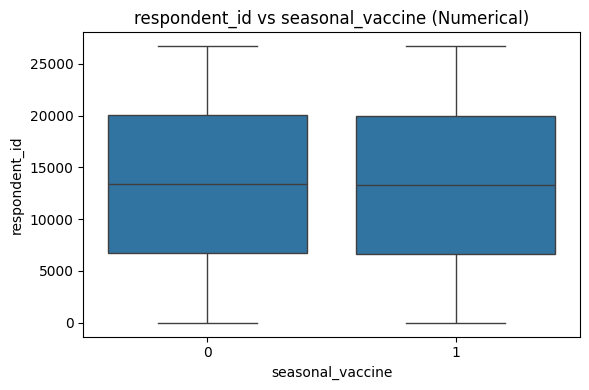

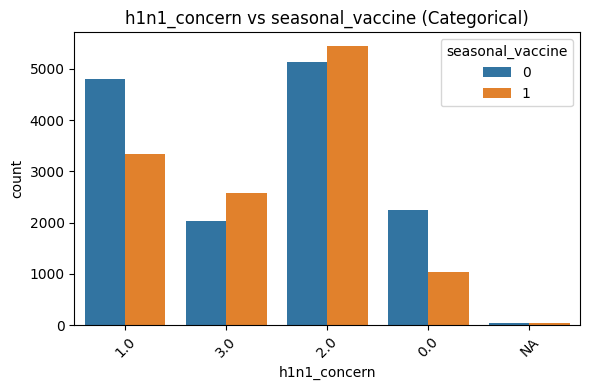

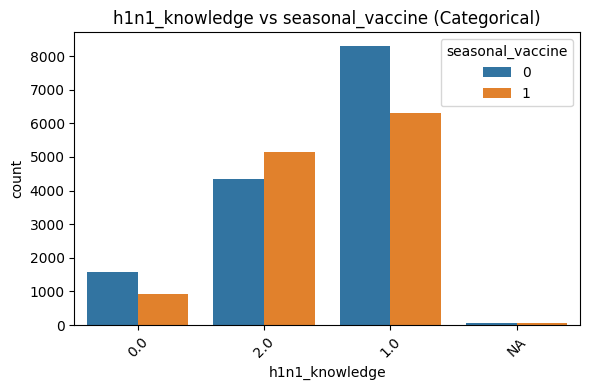

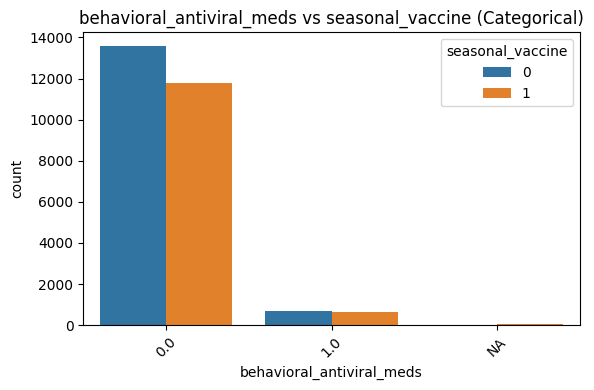

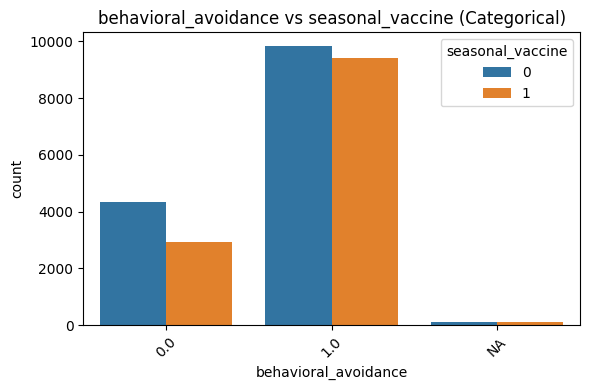

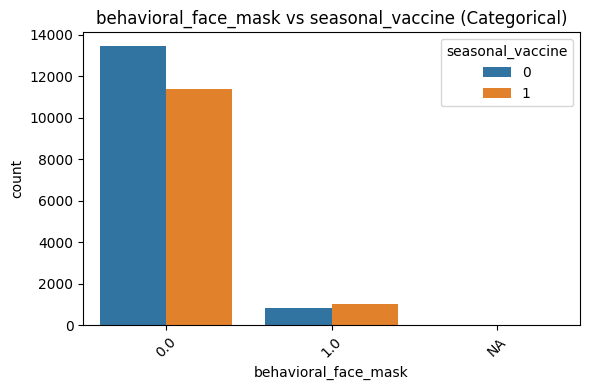

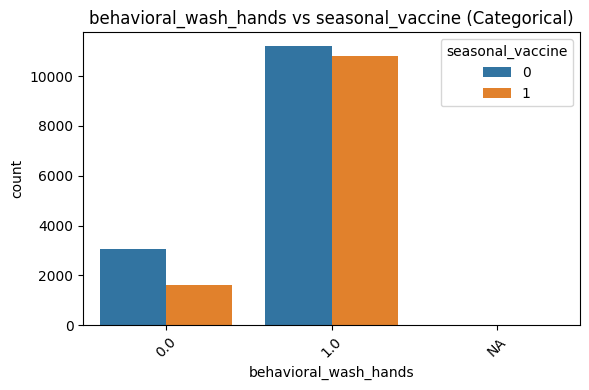

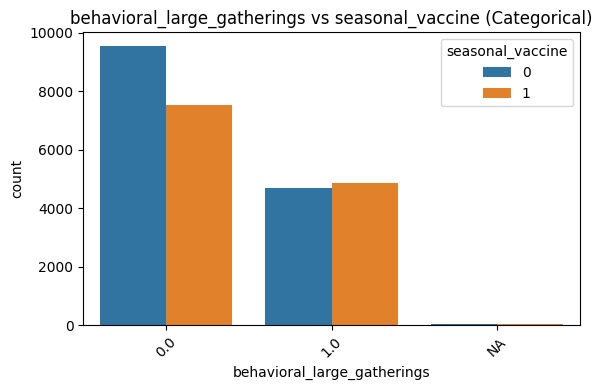

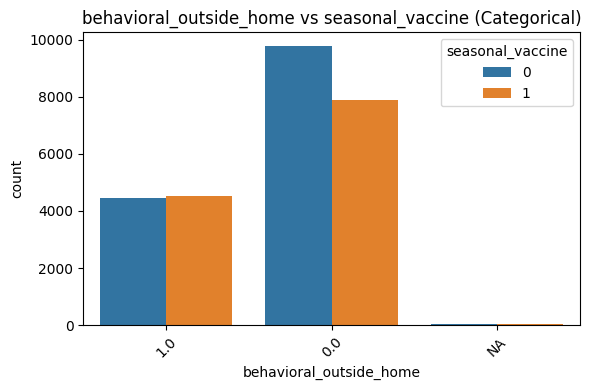

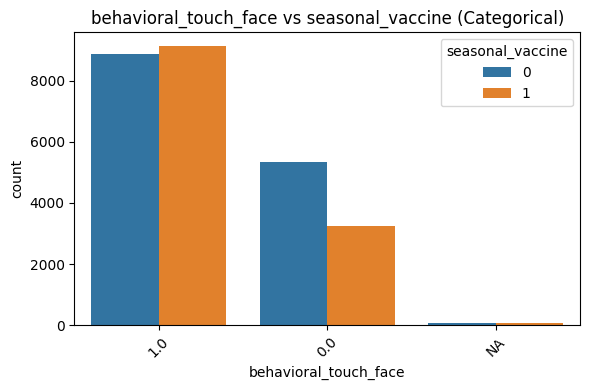

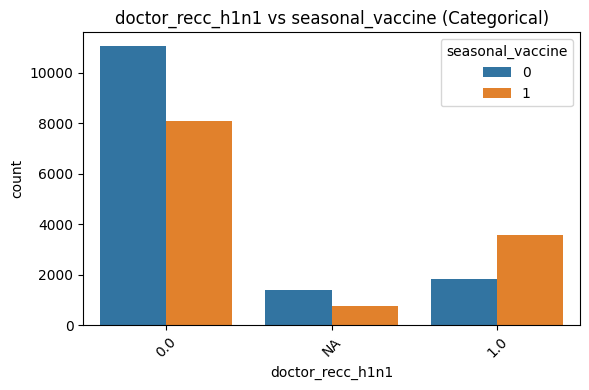

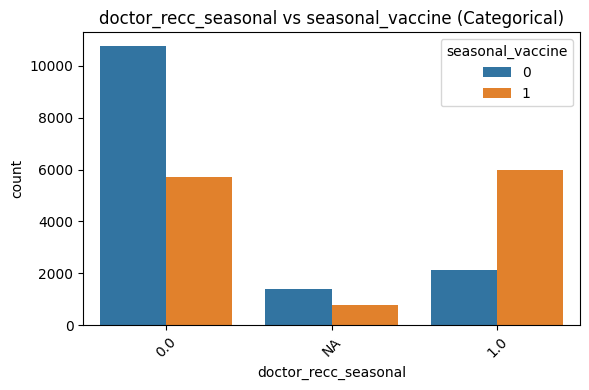

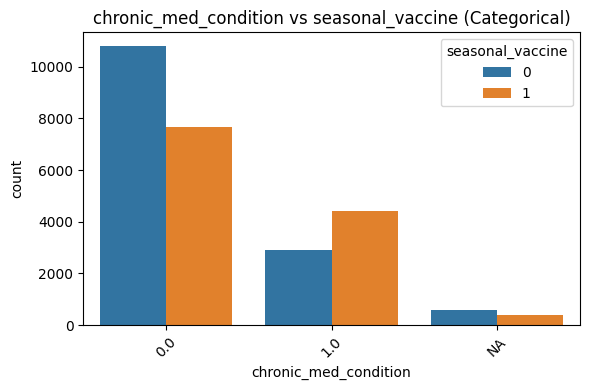

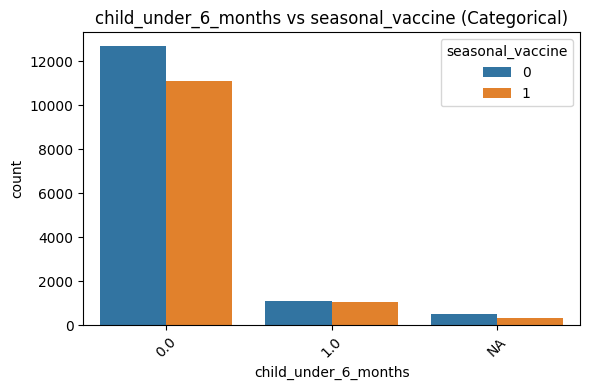

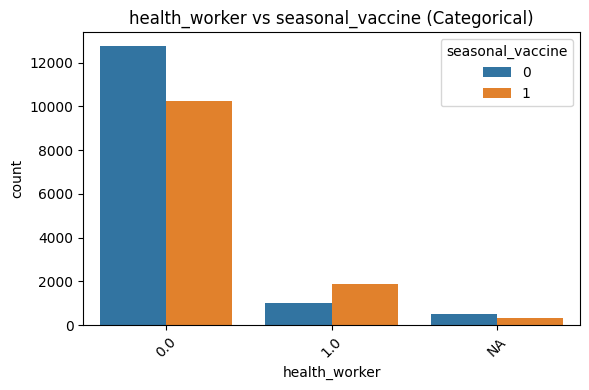

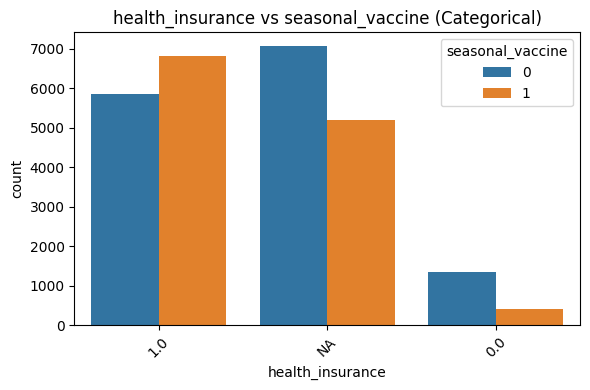

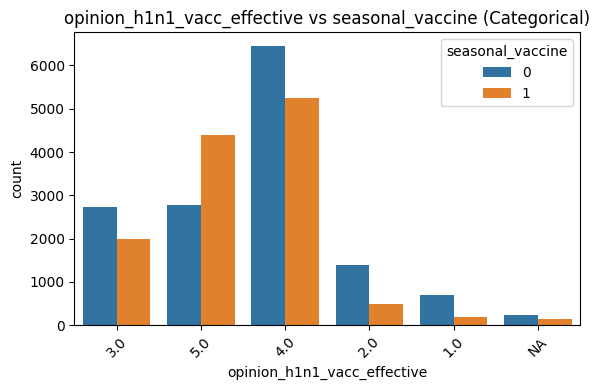

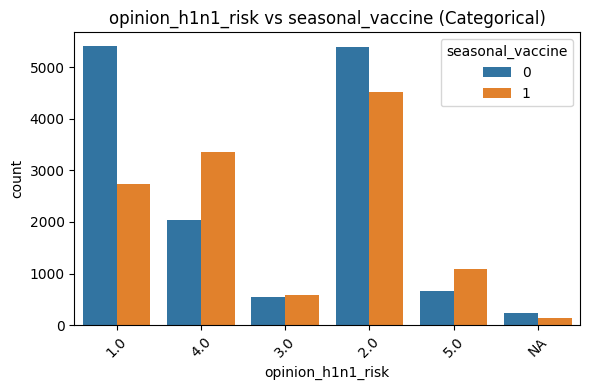

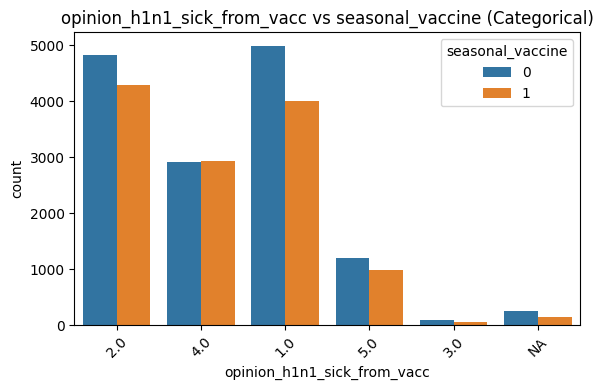

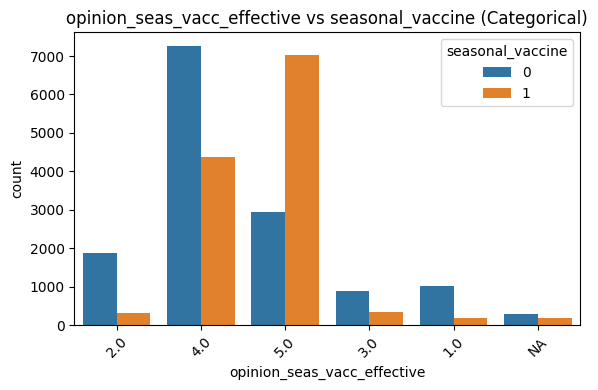

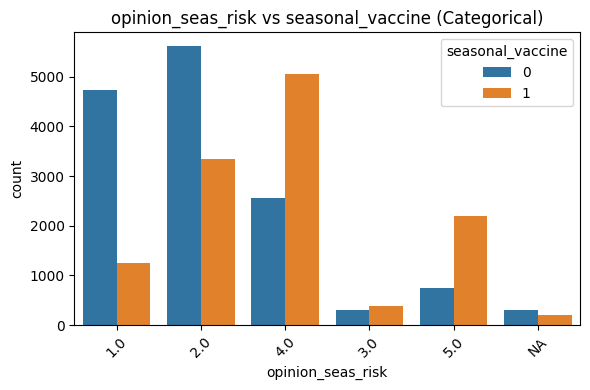

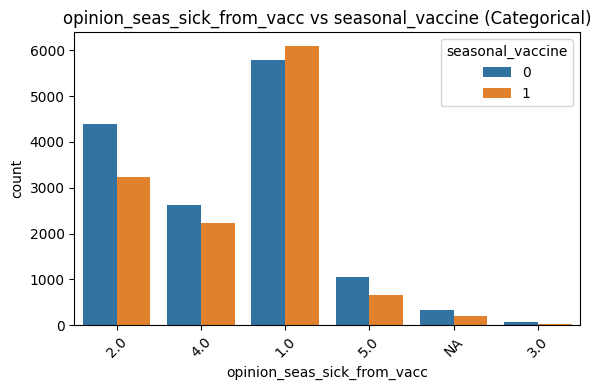

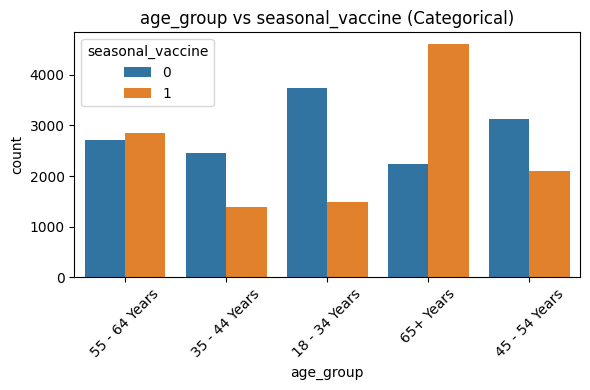

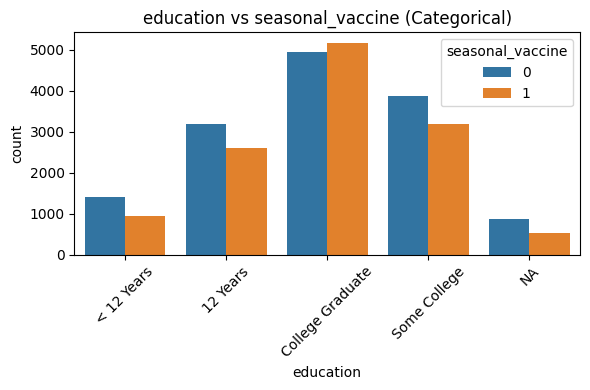

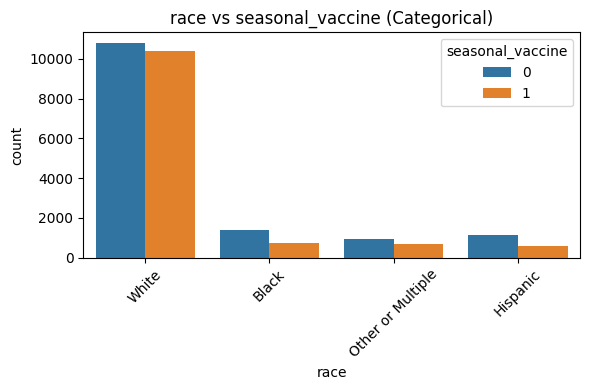

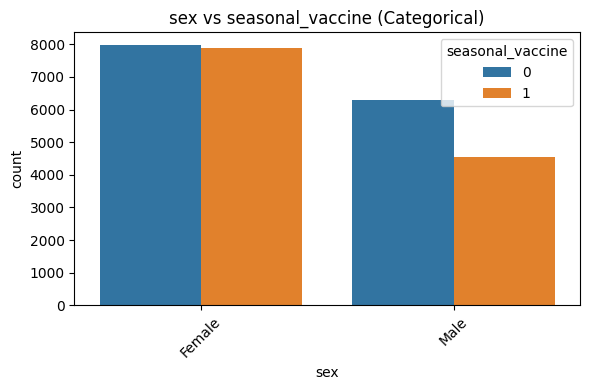

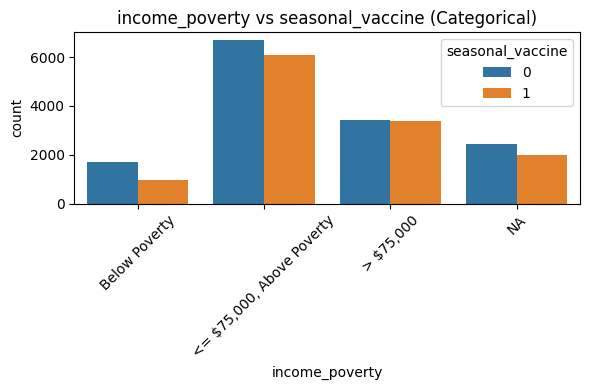

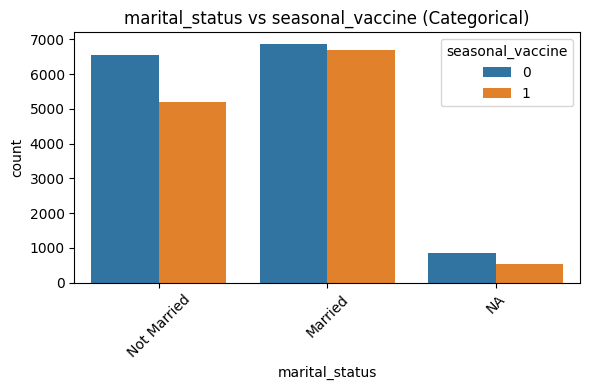

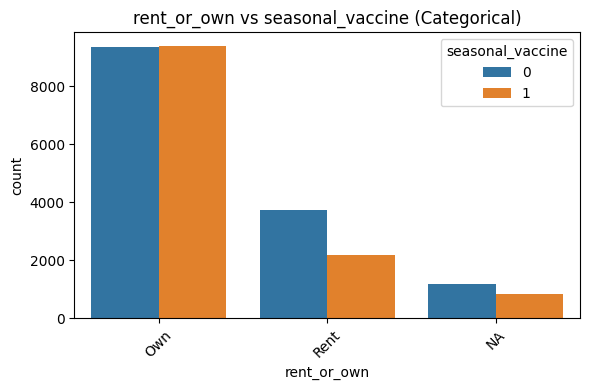

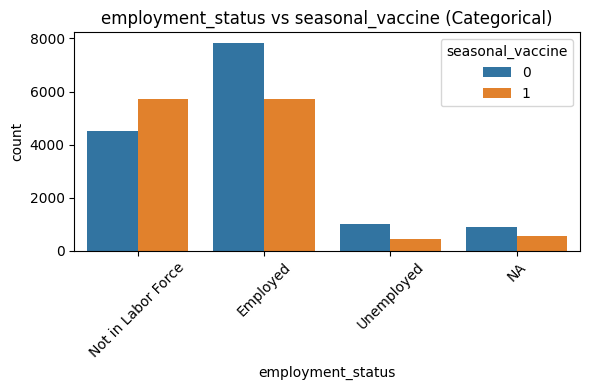

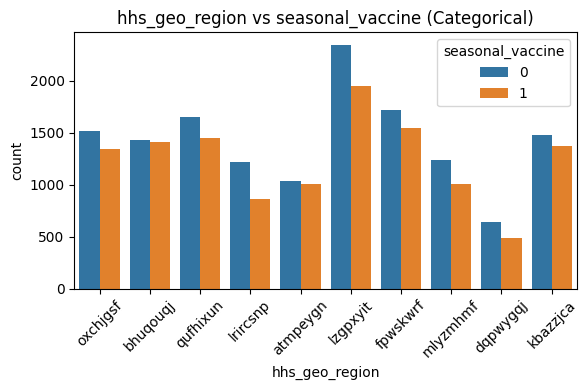

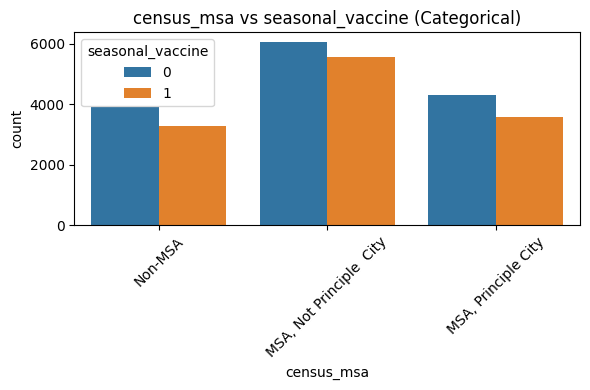

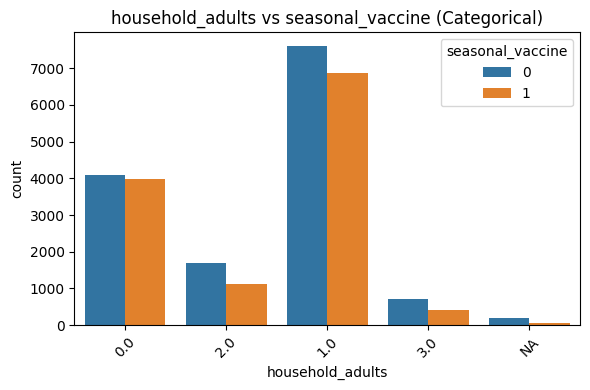

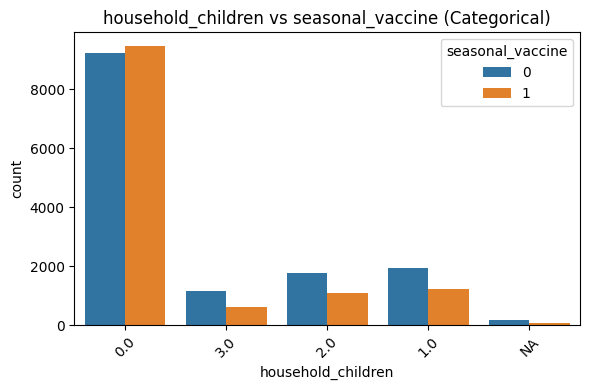

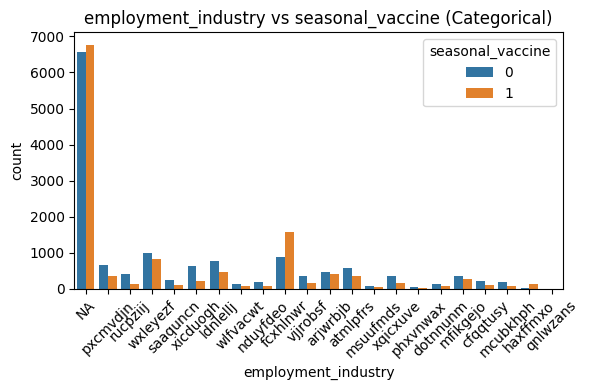

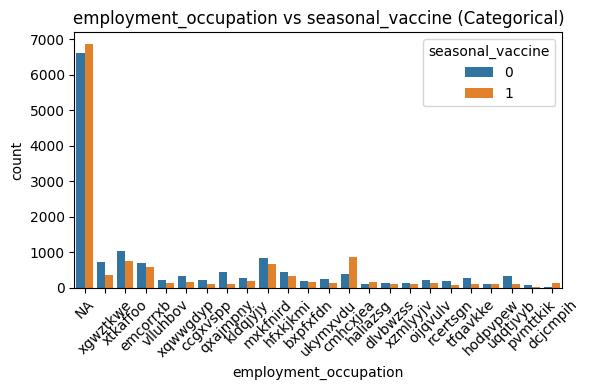

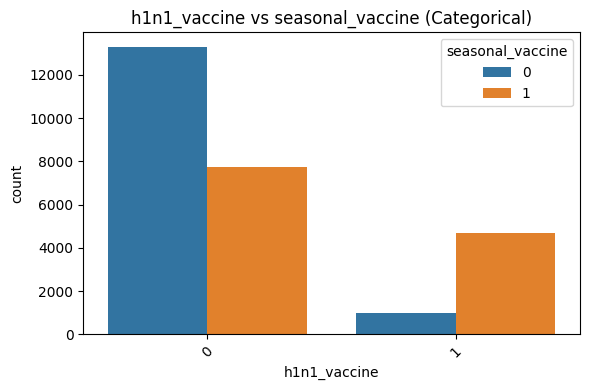

In [25]:
plot_all_vs_target(flu_combinado,'seasonal_vaccine')


In [26]:
flu_final_df = pd.concat([flu_df, flu_test_df])
flu_final_df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


Haremos la imputación de variables de acuerdo a las siguientes reglas como vimos en el análisis exploratiorio

Health_insurance: Codificación explicita con ‘wo_info’, yes y no

Education: random ponderada

Income_poverty: random ponderada

Marital_status: random ponderada

rent_or_own: nueva categoria ‘wo info’

Employment_status: nueva categoria ‘wo info’

Household_adults y household_children: random ponderada

Employment_industry, employment_occupation: Nulos por ‘no job’

El resto: imputacion por la moda


In [27]:

def custom_imputation(df):
    df = df.copy()

    # Health_insurance: codificación explícita
    df['health_insurance'] = df['health_insurance'].map({1: 'yes', 0: 'no'})
    df['health_insurance'].fillna('wo_info', inplace=True)

    # Imputación aleatoria ponderada
    def random_weighted_impute(series):
        probs = series.value_counts(normalize=True)
        return series.apply(lambda x: np.random.choice(probs.index, p=probs.values) if pd.isna(x) else x)

    for col in ['education', 'income_poverty', 'marital_status', 'household_adults', 'household_children']:
        df[col] = random_weighted_impute(df[col])

    # Nueva categoría 'wo_info'
    for col in ['rent_or_own', 'employment_status']:
        df[col] = df[col].fillna('wo_info')

    # Nulos por 'no job'
    for col in ['employment_industry', 'employment_occupation']:
        df[col] = df[col].fillna('no_job')

    # Resto por moda
    excluded = ['health_insurance', 'education', 'income_poverty', 'marital_status',
                'rent_or_own', 'employment_status', 'household_adults', 'household_children',
                'employment_industry', 'employment_occupation']

    for col in df.columns:
        if col not in excluded:
            mode = df[col].mode(dropna=True)
            if not mode.empty:
                df[col] = df[col].fillna(mode[0])

    return df


In [28]:
flu_imputed=custom_imputation(flu_final_df)

In [29]:
#EDA Básico

flu_imputed.info()
flu_imputed.describe()
flu_imputed.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 53415 entries, 0 to 26707
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                53415 non-null  int64  
 1   h1n1_concern                 53415 non-null  float64
 2   h1n1_knowledge               53415 non-null  float64
 3   behavioral_antiviral_meds    53415 non-null  float64
 4   behavioral_avoidance         53415 non-null  float64
 5   behavioral_face_mask         53415 non-null  float64
 6   behavioral_wash_hands        53415 non-null  float64
 7   behavioral_large_gatherings  53415 non-null  float64
 8   behavioral_outside_home      53415 non-null  float64
 9   behavioral_touch_face        53415 non-null  float64
 10  doctor_recc_h1n1             53415 non-null  float64
 11  doctor_recc_seasonal         53415 non-null  float64
 12  chronic_med_condition        53415 non-null  float64
 13  child_under_6_months 

,0
respondent_id,0
h1n1_concern,0
h1n1_knowledge,0
behavioral_antiviral_meds,0
behavioral_avoidance,0
behavioral_face_mask,0
behavioral_wash_hands,0
behavioral_large_gatherings,0
behavioral_outside_home,0
behavioral_touch_face,0


Hemos eliminado todos los nulos

In [30]:
flu_combinado_imputed=custom_imputation(flu_combinado)

**Selección de variables**

**Information Value (IV)**

El IV evalúa la capacidad de una variable para separar las clases del objetivo. Se basa en la distribución de “buenos” y “malos” (o cualquier binaria) en cada categoría o bin de la variable.

IV = Σ (Distribución de buenos - Distribución de malos) × ln(Distribución de buenos / Distribución de malos)

IV <0.02 - Variable no predictiva


In [32]:
tabla4 = pd.crosstab( flu_combinado['opinion_seas_vacc_effective'].fillna('NA'),flu_combinado['seasonal_vaccine'].fillna('NA'))
tabla4

seasonal_vaccine,0,1
opinion_seas_vacc_effective,,
1.0,1028,193
2.0,1885,321
3.0,876,340
4.0,7253,4376
5.0,2945,7028
NA,285,177


In [33]:
import pandas as pd
import numpy as np

def calcular_iv(df, target="seasonal_vaccine", excluir=[]):
    iv_dict = {}

    for col in df.columns:
        if col == target or col in excluir:
            continue

        # Convertir a string para tratar todo como categórico
        serie = df[col].astype(str)
        cruzada = pd.crosstab(serie, df[target])

        # Evitar columnas sin ambas clases
        if cruzada.shape[1] < 2:
            continue

        total_0 = cruzada[0].sum()
        total_1 = cruzada[1].sum()

        cruzada["dist_0"] = cruzada[0] / total_0
        cruzada["dist_1"] = cruzada[1] / total_1

        cruzada["woe"] = np.log((cruzada["dist_1"] + 1e-6) / (cruzada["dist_0"] + 1e-6))
        cruzada["iv"] = (cruzada["dist_1"] - cruzada["dist_0"]) * cruzada["woe"]

        iv_dict[col] = cruzada["iv"].sum()

    iv_df = pd.DataFrame.from_dict(iv_dict, orient="index", columns=["IV"]).sort_values("IV", ascending=False)
    return iv_df

In [34]:
iv_resultados = calcular_iv(flu_combinado_imputed, excluir=["respondent_id","h1n1_vaccine"])
print(iv_resultados)

                                   IV
opinion_seas_vacc_effective  0.708632
opinion_seas_risk            0.662419
doctor_recc_seasonal         0.555097
age_group                    0.341993
opinion_h1n1_risk            0.200089
opinion_h1n1_vacc_effective  0.196338
employment_industry          0.178492
doctor_recc_h1n1             0.162110
employment_occupation        0.160824
health_insurance             0.119343
chronic_med_condition        0.116320
h1n1_concern                 0.101960
employment_status            0.098945
health_worker                0.065988
h1n1_knowledge               0.059588
household_children           0.059459
behavioral_touch_face        0.058638
behavioral_wash_hands        0.052253
rent_or_own                  0.049884
race                         0.045658
opinion_seas_sick_from_vacc  0.032866
sex                          0.023989
behavioral_avoidance         0.023516
education                    0.020100
household_adults             0.019662
income_pover

In [35]:
# Filtrar variables con IV > 0.02
variables_utiles = iv_resultados[iv_resultados["IV"] > 0.02].index.tolist()

# Incluir también la variable objetivo 'Rseasonal_vaccine' en el nuevo DataFrame
flu_filtrado = flu_combinado_imputed[variables_utiles + ["seasonal_vaccine","respondent_id"]]
flu_filtrado.head()

,opinion_seas_vacc_effective,opinion_seas_risk,doctor_recc_seasonal,age_group,opinion_h1n1_risk,opinion_h1n1_vacc_effective,employment_industry,doctor_recc_h1n1,employment_occupation,health_insurance,...,behavioral_touch_face,behavioral_wash_hands,rent_or_own,race,opinion_seas_sick_from_vacc,sex,behavioral_avoidance,education,seasonal_vaccine,respondent_id
0,2.0,1.0,0.0,55 - 64 Years,1.0,3.0,no_job,0.0,no_job,yes,...,1.0,0.0,Own,White,2.0,Female,0.0,< 12 Years,0,0
1,4.0,2.0,0.0,35 - 44 Years,4.0,5.0,pxcmvdjn,0.0,xgwztkwe,yes,...,1.0,1.0,Rent,White,4.0,Male,1.0,12 Years,1,1
2,4.0,1.0,0.0,18 - 34 Years,1.0,3.0,rucpziij,0.0,xtkaffoo,wo_info,...,0.0,0.0,Own,White,2.0,Male,1.0,College Graduate,0,2
3,5.0,4.0,1.0,65+ Years,3.0,3.0,no_job,0.0,no_job,wo_info,...,0.0,1.0,Rent,White,1.0,Female,1.0,12 Years,1,3
4,3.0,1.0,0.0,45 - 54 Years,3.0,3.0,wxleyezf,0.0,emcorrxb,wo_info,...,1.0,1.0,Own,White,4.0,Female,1.0,Some College,0,4


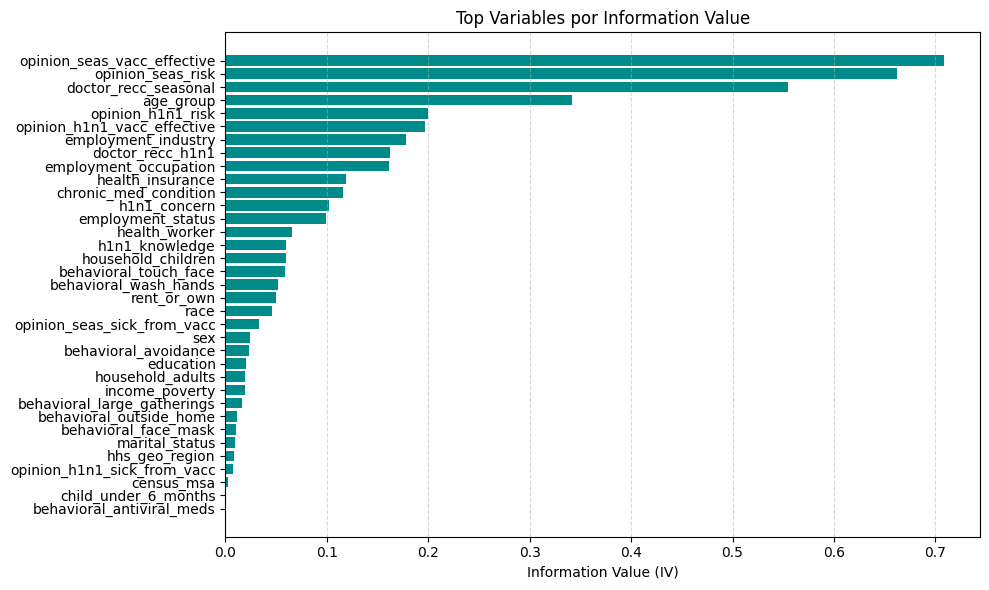

In [36]:
# Convertir serie en DataFrame
flu_iv_df = iv_resultados.reset_index()
flu_iv_df.columns = ['Variable', 'IV']
flu_iv_df = flu_iv_df.sort_values('IV', ascending=True)


# Graficar
plt.figure(figsize=(10, 6))
plt.barh(flu_iv_df['Variable'], flu_iv_df['IV'], color='darkcyan')
plt.xlabel('Information Value (IV)')
plt.title('Top Variables por Information Value')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [37]:
flu_imputed_filtrado=flu_imputed[variables_utiles + ["respondent_id"]]
flu_imputed_filtrado.head()

,opinion_seas_vacc_effective,opinion_seas_risk,doctor_recc_seasonal,age_group,opinion_h1n1_risk,opinion_h1n1_vacc_effective,employment_industry,doctor_recc_h1n1,employment_occupation,health_insurance,...,household_children,behavioral_touch_face,behavioral_wash_hands,rent_or_own,race,opinion_seas_sick_from_vacc,sex,behavioral_avoidance,education,respondent_id
0,2.0,1.0,0.0,55 - 64 Years,1.0,3.0,no_job,0.0,no_job,yes,...,0.0,1.0,0.0,Own,White,2.0,Female,0.0,< 12 Years,0
1,4.0,2.0,0.0,35 - 44 Years,4.0,5.0,pxcmvdjn,0.0,xgwztkwe,yes,...,0.0,1.0,1.0,Rent,White,4.0,Male,1.0,12 Years,1
2,4.0,1.0,0.0,18 - 34 Years,1.0,3.0,rucpziij,0.0,xtkaffoo,wo_info,...,0.0,0.0,0.0,Own,White,2.0,Male,1.0,College Graduate,2
3,5.0,4.0,1.0,65+ Years,3.0,3.0,no_job,0.0,no_job,wo_info,...,0.0,0.0,1.0,Rent,White,1.0,Female,1.0,12 Years,3
4,3.0,1.0,0.0,45 - 54 Years,3.0,3.0,wxleyezf,0.0,emcorrxb,wo_info,...,0.0,1.0,1.0,Own,White,4.0,Female,1.0,Some College,4


**Label encoding**

In [38]:
X = flu_filtrado.drop(['respondent_id', 'seasonal_vaccine'], axis=1)
y = flu_filtrado['seasonal_vaccine']

In [39]:
categorical_cols = [cname for cname in X .columns if
                   X [cname].dtype == "object"]

categorical_cols

['age_group',
 'employment_industry',
 'employment_occupation',
 'health_insurance',
 'employment_status',
 'rent_or_own',
 'race',
 'sex',
 'education']

In [40]:
flu_test_final =  flu_imputed_filtrado [flu_imputed_filtrado  ["respondent_id"].isin(flu_test_df["respondent_id"])]
flu_test_final.head()

,opinion_seas_vacc_effective,opinion_seas_risk,doctor_recc_seasonal,age_group,opinion_h1n1_risk,opinion_h1n1_vacc_effective,employment_industry,doctor_recc_h1n1,employment_occupation,health_insurance,...,household_children,behavioral_touch_face,behavioral_wash_hands,rent_or_own,race,opinion_seas_sick_from_vacc,sex,behavioral_avoidance,education,respondent_id
0,5.0,1.0,0.0,35 - 44 Years,1.0,5.0,atmlpfrs,0.0,hfxkjkmi,yes,...,0.0,1.0,1.0,Rent,Hispanic,1.0,Female,1.0,College Graduate,26707
1,4.0,1.0,0.0,18 - 34 Years,1.0,4.0,atmlpfrs,0.0,xqwwgdyp,no,...,0.0,0.0,0.0,Rent,White,1.0,Male,0.0,12 Years,26708
2,5.0,4.0,0.0,55 - 64 Years,4.0,5.0,nduyfdeo,0.0,pvmttkik,wo_info,...,0.0,1.0,1.0,Own,White,4.0,Male,0.0,College Graduate,26709
3,4.0,4.0,1.0,65+ Years,2.0,4.0,no_job,1.0,no_job,yes,...,0.0,0.0,0.0,Own,White,2.0,Female,0.0,12 Years,26710
4,4.0,4.0,0.0,35 - 44 Years,2.0,5.0,fcxhlnwr,0.0,mxkfnird,yes,...,1.0,1.0,1.0,Own,Black,2.0,Female,1.0,12 Years,26711


In [41]:

# entrenar y ajustar el label encoded
for col in categorical_cols:
  le = LabelEncoder()
  flu_filtrado[col] = le.fit_transform(flu_filtrado[col])
  flu_test_final[col] = le.transform(flu_test_final[col])

In [42]:
#exporto a csv para usarlo después en el resto de modelos

# Exportar a CSV
flu_filtrado.to_csv("flu_filtrado_codificado.csv", index=False)
flu_test_final.to_csv("flu_test_final_codificado.csv", index=False)


In [43]:
# Valido que se hayan convertido los tipos
print(flu_filtrado.dtypes)

opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
doctor_recc_seasonal           float64
age_group                        int64
opinion_h1n1_risk              float64
opinion_h1n1_vacc_effective    float64
employment_industry              int64
doctor_recc_h1n1               float64
employment_occupation            int64
health_insurance                 int64
chronic_med_condition          float64
h1n1_concern                   float64
employment_status                int64
health_worker                  float64
h1n1_knowledge                 float64
household_children             float64
behavioral_touch_face          float64
behavioral_wash_hands          float64
rent_or_own                      int64
race                             int64
opinion_seas_sick_from_vacc    float64
sex                              int64
behavioral_avoidance           float64
education                        int64
seasonal_vaccine                 int64
respondent_id            

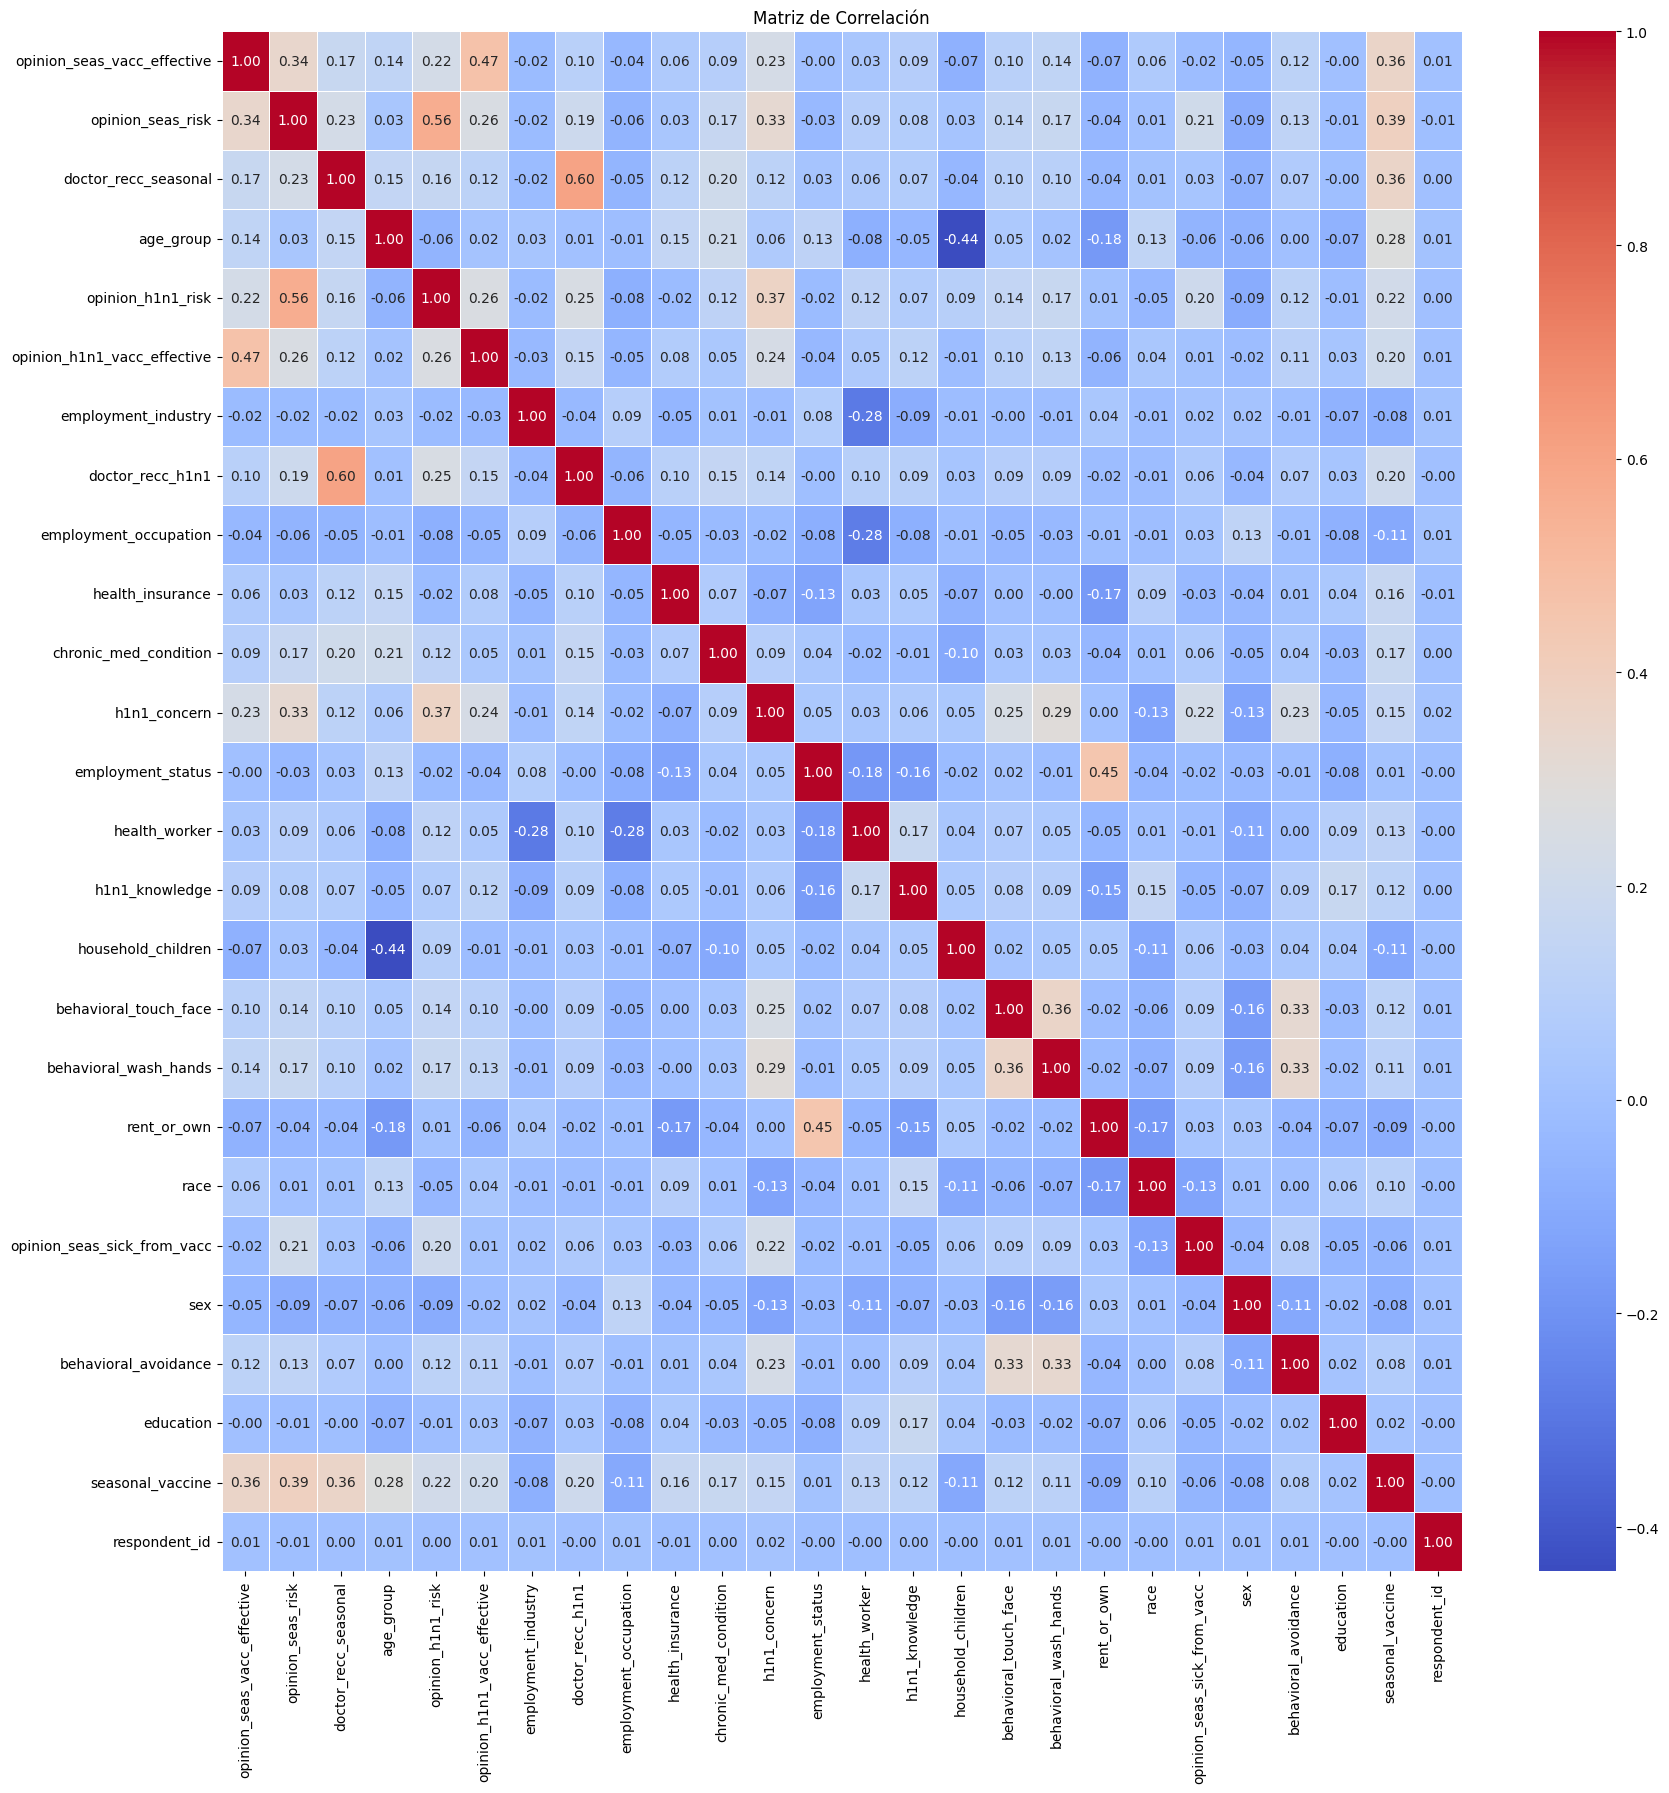

In [44]:
#Excluyo las variables no numericas (el target)
numeric_flu = flu_filtrado.select_dtypes(include=[np.number])

# Generar la matriz de correlación
correlation_matrix = numeric_flu.corr()

# Imprimir la matriz de correlación

# Visualizar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

No existen correlaciones significativas